In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pickle
import glob
import sys

# Make local code importable (expects Code/compute_session_alignment.py)
sys.path.append('./Code/')
import compute_session_alignment

from collections import Counter
from joblib import Parallel, delayed

# ---------------------------------------------------------------------
# Decoders: mean‐template variants
# ---------------------------------------------------------------------
def letter_decoding_mean(x_train, x_test, y_train, y_test, shuffle=False):
    """
    Mean‐template decoding that compares per‐class mean TEST activity to
    per‐class mean TRAIN templates using cosine similarity, but counts
    accuracy at the **class‐mean** level (i.e., 1 correct per class).

    Args
    ----
    x_train, x_test : array (trials × time × features) BEFORE windowing.
    y_train, y_test : array (trials,) with discrete class labels.
    shuffle         : bool, if True shuffles y labels for a null/control.

    Returns
    -------
    score_matrix : (n_win × n_win) array of counts (not normalized).
                   Entry (ti, tj) = number of classes correctly predicted
                   when training a template at window ti and testing on
                   class means at window tj.
    n_classes    : int, number of unique classes present in training labels.
    """
    
    n_win = len(window_ranges)
    score_matrix = np.zeros((n_win, n_win))

    # Copy/alias labels (already integers/strings)
    y_train_encoded = y_train
    y_test_encoded  = y_test
    class_labels    = [0,1] #np.unique(y_train_encoded)

    # Average activity in sliding windows and baseline‐correct by FIX bins
    #print((x_train.shape,x_test.shape),flush=True)
    xTTrain_all = [np.mean(x_train[:, start:end, :], axis=1) #- np.mean(x_train[:, 0:4, :], axis=1)
                   for (start, end) in window_ranges]
    xTTest_all  = [np.mean(x_test[:, start:end, :], axis=1)  #- np.mean(x_test[:, 0:4, :], axis=1)
                   for (start, end) in window_ranges]

    if shuffle:
        # Shuffle labels independently for train/test for a conservative null
        np.random.shuffle(y_train_encoded)
        np.random.shuffle(y_test_encoded)

    all_templates = []  # keep templates from each TRAIN window (for inspection)
    for ti, xTTrain in enumerate(xTTrain_all):
        for tj, xTTest in enumerate(xTTest_all):
            if(ti==tj):
                # --- TRAIN: build one mean template per class (in window ti)
                templates = []
                for c in class_labels:
                    class_indices = np.where(y_train_encoded == c)[0]
                    template = np.mean(xTTrain[class_indices], axis=0)
                    templates.append(template)
                templates = np.array(templates)  # (n_classes × n_features)

                if tj == 0:
                    all_templates.append(templates)

                # --- TEST: compare per‐class MEAN test activity to templates
                correct = 0
                for c_idx, c in enumerate(class_labels):
                    test_indices = np.where(y_test_encoded == c)[0]
                    if len(test_indices) == 0:
                        continue

                    # mean vector for THIS class/window
                    test_vec = np.mean(xTTest[test_indices], axis=0)

                    # Cosine similarity to each template -> scalars
                    corrs = [
                        float(np.dot(test_vec, tpl) / (np.linalg.norm(test_vec) * np.linalg.norm(tpl) + 1e-8))
                        for tpl in templates
                    ]

                    # tie-break
                    if len(corrs) == 2 and np.isclose(corrs[0], corrs[1]):
                        predicted_class_idx = np.random.choice([0, 1])
                    else:
                        predicted_class_idx = int(np.argmax(corrs))

                    predicted_class = class_labels[predicted_class_idx]
                    if predicted_class == c:
                        correct += 1
                        

            score_matrix[ti, tj] = correct  # raw count (not %)
            
    return score_matrix, 2, #len(class_labels)

In [2]:
units = np.load('../Data/units.npy',allow_pickle=True)
units[6][0]

array(['uAHL1_0', 'uAHL1_4', 'uAHL1_5', 'uAHL2_0', 'uAHL3_0', 'uAHL4_1',
       'uAHL5_0', 'uAHL7_1', 'uAHL7_4', 'uAL8_17', 'uAL8_19', 'uECL3_14',
       'uPHL2_3', 'uPHR1_1', 'uPHR3_5', 'uPHR5_1', 'uPHR6_2', 'uPHR6_4',
       'uPHR6_5', 'uPHR6_6', 'uPHR6_7', 'uPHR6_8', 'uPHR6_9', 'uPHR7_16',
       'uPHR7_2', 'uPHR7_3', 'uPHR7_8'], dtype=object)

In [3]:
completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
completeBinned[1].shape

(99, 16, 16)

In [4]:
letters        = np.load('../Data/letters.npy')
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
uniqueLetters

array(['B', 'C', 'D', 'F', 'G', 'H', 'K', 'L', 'N', 'P', 'R', 'S', 'T',
       'V', 'Z'], dtype='<U1')

In [5]:
subj_ses = np.load('../Data/subjs_sep.npy',allow_pickle=True)
len(subj_ses)

35

In [21]:
subj_single  = np.array([subj_ses[i][0] for i in range(len(subj_ses))])
units_single = [units[i][0] for i in range(len(units))]

In [26]:
len(units_single)

35

In [6]:
selective_neurons = np.load('../selective_neurons.npy',allow_pickle=True)
selective_neurons

array([array([4, 5]), array([], dtype=int64), array([], dtype=int64),
       array([ 9, 10, 11]), array([ 3,  5, 12, 17]), array([ 0, 20]),
       array([21]), array([14]), array([ 0, 16, 24]),
       array([12, 33, 38, 46, 48, 49, 58]), array([12]),
       array([], dtype=int64), array([9]), array([], dtype=int64),
       array([], dtype=int64), array([30]), array([17]), array([4]),
       array([30]), array([18]), array([ 5,  6, 14, 16]),
       array([], dtype=int64), array([ 2, 10]),
       array([ 2, 44, 48, 61, 76]), array([15, 23, 48]), array([25, 29]),
       array([ 1,  7, 23, 33, 65, 76, 89, 94]), array([3]), array([4]),
       array([], dtype=int64), array([4, 5]), array([2, 3]),
       array([ 2, 10]), array([7]), array([11])], dtype=object)

In [34]:
allLOCS = []
for s in np.unique(subj_single):
    locs = []
    subj_neurons = selective_neurons[subj_single==s]
    unit_neurons = [units_single[wi] for wi in np.where(subj_single==s)[0]]
    for i in range(len(subj_neurons)):
        sn = subj_neurons[i]
        un = unit_neurons[i]
        if(len(sn)):
            locs.extend(un[sn])
    locs = [l.split('_')[0][1:-1] for l in locs]
    print(s, np.sum([len(n) for n in subj_neurons]), locs)
    allLOCS.append(locs)

from collections import Counter
listLOCS = np.concatenate(allLOCS)
Counter(listLOCS)

40 9 ['AL', 'AL', 'AL', 'AHL', 'AHL', 'AHL', 'PHR', 'AL', 'PHR']
43 9 ['AHL', 'AHR', 'AR', 'PHL', 'PHL', 'PHL', 'PHL', 'PHR', 'AHR']
44 10 ['AHR', 'PHR', 'PHR', 'PHR', 'PHR', 'ECL', 'ECL', 'PHR', 'PHR', 'PHR']
45 2 ['AL', 'ECR']
47 5 ['PHR', 'PHL', 'PHL', 'PHR', 'PHR']
53 4 ['PHR', 'AR', 'AHL', 'PHL']
57 1 ['AL']
58 11 ['AHL', 'AHL', 'AHL', 'AHL', 'ECL', 'ECL', 'ECL', 'ECL', 'ECL', 'ECL', 'AL']
61 4 ['AHL', 'PHL', 'PHR', 'PHR']
63 7 ['AR', 'AR', 'AR', 'AR', 'AR', 'AR', 'AR']
64 2 ['AHL', 'AHL']


Counter({'AL': 7,
         'AHL': 12,
         'PHR': 16,
         'AHR': 3,
         'AR': 9,
         'PHL': 8,
         'ECL': 8,
         'ECR': 1})

In [35]:
units = np.load('../Data/units.npy',allow_pickle=True)
subj  = np.load('../Data/subjs_sep.npy',allow_pickle=True)
subj  = [s[0] for s in subj]

HYP = 0
AMY = 0
ENT = 0

for i in range(len(units)):
    u = units[i][0]
    for ui in u:
        if('AH' in ui or 'PH' in ui):
            HYP += 1
        elif('AL' in ui or 'AR' in ui):
            AMY += 1
        else:
            ENT += 1

In [36]:
# Count selective neurons per area
HYP_sel = 0
AMY_sel = 0
ENT_sel = 0

for loc in listLOCS:
    if 'AH' in loc or 'PH' in loc:
        HYP_sel += 1
    elif 'AL' in loc or 'AR' in loc:
        AMY_sel += 1
    else:
        ENT_sel += 1

# Total neurons per area (from your existing loop above)
print(f"Selective neurons — HYP: {HYP_sel}, AMY: {AMY_sel}, ENT: {ENT_sel}")
print(f"Total neurons    — HYP: {HYP}, AMY: {AMY}, ENT: {ENT}")
print()
print(f"% selective — HYP: {100*HYP_sel/HYP:.1f}%")
print(f"% selective — AMY: {100*AMY_sel/AMY:.1f}%")
print(f"% selective — ENT: {100*ENT_sel/ENT:.1f}%")

Selective neurons — HYP: 39, AMY: 16, ENT: 9
Total neurons    — HYP: 559, AMY: 239, ENT: 198

% selective — HYP: 7.0%
% selective — AMY: 6.7%
% selective — ENT: 4.5%


In [7]:
from copy import deepcopy
NPC_TO_ALIGN = 5
# ---------------------------------------------------------------------
# Shared/static variables (loaded once)
# ---------------------------------------------------------------------
# NOTE: The following variables are referenced later. Make sure they are
# defined prior to calling functions that use them.

# Load all data (paths assume ../Data/ exists)
probes         = np.load('../Data/probes.npy')
subj           = np.load('../Data/subjs.npy')
subj_ses       = np.load('../Data/subjs_sep.npy', allow_pickle=True)
inout          = np.load('../Data/in.npy')
letters        = np.load('../Data/letters.npy')
letters_ses    = np.load('../Data/letters_sep.npy', allow_pickle=True)
probes_ses     = np.load('../Data/probes_sep.npy', allow_pickle=True)
units          = np.load('../Data/units.npy',allow_pickle=True)

# Subject/session metadata
sses          = [s[0] for s in subj_ses]
uniqueSub     = np.unique(sses)

# Letters (exclude rarely used or unwanted letters)
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
n_labels      = len(uniqueLetters)

# Sliding windows: 4 bins wide, sliding by 1 bin (29 positions)
window_ranges = [(i, i + 1) for i in range(16)]

# ---------------------------------------------------------------------
# One permutation "trial": align, project, decode (for one letter)
# ---------------------------------------------------------------------
t1 = 2
t2 = 16
def single_trial(ktrial, letter_index):
    retry = 0 
    ok = False
    while not ok:
        maskSub = [subj_ses[i][0]!=outSub for i in range(len(subj_ses))]
        completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
        completeBinned = completeBinned[maskSub]
        #Counter(subj)

        data = []
        train_test_labels = []

        Y      = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in letters_ses[maskSub]]
        
        Yprobe = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in probes_ses[maskSub]]
         
        maskSET_TEST  = [np.sum(yi,axis=1)>0 for yi in Y]
        maskSET_TRAIN = [np.sum(yi,axis=1)>0 for yi in Y]
        
        #maskSET_TEST  = [np.sum(yi*yp,axis=1)>=0 for (yi,yp) in zip(Y,Yprobe)]
        #maskSET_TRAIN = [np.sum(yi*yp,axis=1)>=0 for (yi,yp) in zip(Y,Yprobe)]
        #print(maskSET_TEST,flush=True)
        
        units =  np.load('../Data/units.npy', allow_pickle=True)
        units = units[maskSub]

        all_maskU = []
        newcompleteBinned = []
        newY = []
        newMaskSET_TEST  = []
        newMaskSET_TRAIN = []
        for i in range(len(completeBinned)):
            
            maskU = [list(np.where(['L' in ui for ui in units[i][0]])[0])+
            #list(np.where(['AHL' in ui for ui in units[i][0]])[0])+
            #list(np.where(['PHR' in ui for ui in units[i][0]])[0])+
            list(np.where(['R' in ui for ui in units[i][0]])[0])][0]
            
            
            bst = completeBinned[i]
            #print(bst.shape,flush=True)
            #print(maskU,flush=True)
            
            bst = bst[:,maskU]
            bst = np.transpose(bst, (1, 2, 0))
            if len(bst) >= NPC_TO_ALIGN:
                newcompleteBinned.append(completeBinned[i])
                newY.append(Y[i])
                newMaskSET_TEST.append(maskSET_TEST[i])
                newMaskSET_TRAIN.append(maskSET_TRAIN[i])
                tt_label  = np.random.uniform(0, 1, len(bst[0][0])) > 0.5
                #tt_label = np.zeros(len(bst[0][0]))
                #tt_label[np.random.choice(np.arange(len(tt_label)),
                #                          size=1,
                #                          replace=False)] = 1

                condition = Y[i][:, letter_index]

                mask    = np.logical_and(tt_label == 0,condition>-1)
                timeB   = np.arange(len(bst[0])) * 0.250
                session = {
                    'response' : bst[:,:,mask],#bst[:, :, tt_label == 0],
                    'condition': condition[mask],#condition[tt_label == 0],
                    'time'     : timeB
                }
                data.append(session)
                all_maskU.append(maskU)
                train_test_labels.append(tt_label)


        pars = {'alignment': {'nPCs_align': NPC_TO_ALIGN, 'cond_contrast': (1, 0),'exclude_units':selective_neurons, "unit_selection": "random"},
                'align_proj': {'condition_vars': []}}

        D_align, D_cond_avg_proj_align, align_stats = compute_session_alignment.compute_session_alignment_CONTRAST_2BIAS_SUBSELECT_BYIDX(data, [], pars,t1,t2)

        Z_align = deepcopy(D_align)
        #print(len(all_maskU),len(train_test_labels),len(newcompleteBinned),len(D_align),newcompleteBinned[0].shape,flush=True)
        X = np.concatenate([Z_align[i]['response'] for i in range(len(Z_align))], axis=2)
        #X = X[accepted_components]
        #projected_X = [
        #    np.transpose(newcompleteBinned[sesID][:,all_maskU[sesID]], (0, 2, 1)) @ D_align[sesID]['U'] + D_align[sesID]['bias'] #[:, accepted_components]
        #    for sesID in range(len(newcompleteBinned))
        #]

        projected_X = []
        for sesID in range(len(newcompleteBinned)):
            unit_idx = D_align[sesID]["unit_idx"]          # indices into ORIGINAL session units
            XSUB = np.transpose(newcompleteBinned[sesID][:, all_maskU[sesID]][:,D_align[sesID]["unit_idx"]], (0, 2, 1))
            projected = XSUB @ D_align[sesID]["U"] + D_align[sesID]["bias"]
            projected_X.append(projected)

        #print(len(projected_X),flush=True)
        X_train = [projected_X[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i])] for i in range(len(train_test_labels))]
        X_test  = [projected_X[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i])] for i in range(len(train_test_labels))]
        Y_train = [newY[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i]), letter_index] for i in range(len(train_test_labels))]
        Y_test  = [newY[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i]), letter_index] for i in range(len(train_test_labels))]
        #Y_probe_test  = [Yprobe[i][train_test_labels[i] == 1, letter_index] for i in range(len(train_test_labels))]

        X_train = np.concatenate(X_train, axis=0)
        X_test  = np.concatenate(X_test, axis=0)
        Y_train = np.concatenate(Y_train, axis=0)
        Y_test  = np.concatenate(Y_test, axis=0)
        
        if( (np.sign(np.mean(X_train[Y_train==1,t1:t2]))*np.sign(np.mean(X_train[Y_train==0,t1:t2])))<0 ):
            ok = True
        else:
            print('retry attempt: ',retry,flush=True)
            retry += 1
    
    
    MW,SUM_IT = letter_decoding_mean(
            X_train,
            X_test,
            Y_train,
            Y_test,
            shuffle=False
        )

    #return [D_align[sesID]['U'] + D_align[sesID]['bias'] for sesID in range(len(completeBinned))]
    return MW,SUM_IT

In [8]:
completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
len(completeBinned)

35

In [9]:
len(selective_neurons)

35

In [10]:
import importlib
importlib.reload(compute_session_alignment)
# ---------------------------------------------------------------------
# Outer loops: run multiple rounds and save per‐letter maps
# ---------------------------------------------------------------------
print(np.unique(subj))
for outSub in [0]: #np.unique(subj):
    print(outSub)
    for qqq in range(50):
        print(qqq)
        all_Letters = []
        for letter_index in range(15):  # first 15 letters from uniqueLetters
            # Run many permutations in parallel and aggregate
            #print(letter_index)
            c = True
            cc = 0 
            while c:
                try:
                    results = Parallel(n_jobs=-1, verbose=0)(
                    delayed(single_trial)(ktrial, letter_index) for ktrial in range(50)
                    )
                    allMW  = [res[0] for res in results if res is not None]
                    allSUM = [res[1] for res in results if res is not None]
                    mean_MW = np.sum(allMW, axis=0) / np.sum(allSUM)
                    all_Letters.append(mean_MW)
                    c = False
                except:
                    cc +=1
                    #print('Error')
                    if(cc >50):
                        continue

        np.save(f'../single_letter_noLetterNeurons_'+str(qqq)+'.npy', all_Letters)

[40 43 44 45 47 53 57 58 61 63 64]
0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


In [11]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patheffects as pe

# ------------------------ load helpers (no shuffling) ------------------------
def load_letter_acc(area_prefix, n_runs=20, n_letters=15):
    stacks = []
    for k in range(n_runs):
        all_Letters = np.load(f'../single_letter_{area_prefix}_{k}.npy')  # (n_letters, n_steps, n_steps)
        diag_per_letter = [np.diag(all_Letters[li]) for li in range(n_letters)]
        stacks.append(np.array(diag_per_letter))
    return np.array(stacks)  # (n_runs, n_letters, n_steps)

acc_HYP = load_letter_acc("noLetterNeurons")

# ------------------------ pick target letters ------------------------
target_letters = ['F','B','G','C','V','D','N','R',
                  'K','T','Z','H','S','L','P']
L    = len(target_letters)
idxs = [np.where(t == uniqueLetters)[0][0] for t in target_letters]

# ------------------------ compute last-step accuracies (no flattening) ------------------------
T1, T2 = 2, 16
T = T2 - T1

def compute_last_true(letter_acc, letter_indices, T1=4, T2=32):
    last_true = np.array([
        np.cumsum(letter_acc[:, i, T1:T2], axis=-1)[:, -1] / (T2 - T1)
        for i in letter_indices
    ])  # (L, n_runs)
    return [last_true[row_ix] for row_ix in range(last_true.shape[0])]

data_HYP = compute_last_true(acc_HYP, idxs, T1=T1, T2=T2)

In [12]:
np.median(data_HYP,axis=-1)

array([0.60107143, 0.56785714, 0.54285714, 0.56607143, 0.55035714,
       0.55607143, 0.53178571, 0.54642857, 0.53142857, 0.50642857,
       0.51071429, 0.49857143, 0.50035714, 0.49178571, 0.47821429])

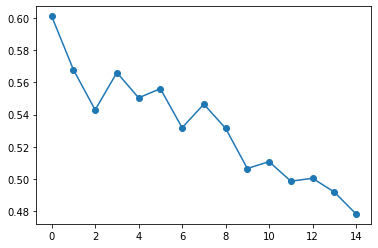

In [13]:
plt.plot(np.median(data_HYP,axis=-1))
plt.scatter(np.arange(15),np.median(data_HYP,axis=-1))